# Proyecto 1: EDA + Baseline

**Ciencia de Datos, Sección A** · Segundo semestre 2026

Entrega: **viernes 11 de septiembre** · 10 puntos

---

**Autor(es):** Philip Falla

**Dataset elegido:** Predict Students' Dropout and Academic Success (UCI Machine Learning Repository, dataset ID 697)

### Rúbrica resumida

| Criterio | Pts | Qué buscamos |
|---|---|---|
| Pregunta y datos | 2 | Pregunta clara, provenance del dataset |
| EDA | 3 | Hallazgos, no galería de gráficas |
| Features | 2 | Cada decisión justificada, sin leakage |
| Baseline | 2 | Validación correcta, métrica adecuada |
| Límites | 1 | Qué no puede concluirse con estos datos |

## 1. Pregunta y contexto

Las universidades suelen identificar tarde, o no suelen hacerlo, a los estudiantes en riesgo de abandonar: para cuando ya llegó el final del semestre, ya es muy tarde. Al tener esta información desde el día en el que se inscribe el estudiante, la universidad podría ofrecer tutorías, becas o seguimiento a quienes más lo necesitan desde el primer semestre, en lugar de esperar a que ya se empieze a abandondar el estudio.

Este proyecto busca explicar si la información personal y socioeconómica tiene influencia en la probabilidad de que un estudiante abandone la carrera. Si el modelo logra ganarle, con un margen claro, a predecir siempre 'no abandona' entonces no es necesario esperar a obtener señales académicas como lo son las notas y asistencia. De esa forma se justificaría invertir en programas de apoyo desde el momento de admisión como un claro diferenciador de la competencia.

**Pregunta:** ¿Qué tanto explica la información personal y socioeconómica de un estudiante (por ejemplo, edad, estado civil, nacionalidad, necesidades educativas especiales, etc.) su probabilidad de abandonar la carrera?

**Tipo de problema:** Clasificación binaria.

**Variable objetivo:** `Target`, recodificada como `dropout` (1 = Dropout, 0 = Enrolled o Graduate). Se colapsan "Enrolled" y "Graduate" en una sola clase de "no abandono" porque la pregunta es específicamente sobre abandono, no sobre distinguir entre seguir inscrito y graduarse.

## 2. Los datos

- **Fuente:** UCI Machine Learning Repository, dataset "Predict Students' Dropout and Academic Success" (ID 697). Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success — DOI: https://doi.org/10.24432/C5MC89
- **Fecha de descarga:** 14 de septiembre de 2026
- **Licencia:** CC BY 4.0 (uso y redistribución permitidos citando la fuente)
- **Unidad de observación:** cada fila es un estudiante matriculado en una carrera de grado de una institución de educación superior portuguesa (varios programas: agronomía, diseño, enfermería, gestión, periodismo, servicio social, tecnologías, entre otros), con cohortes de ingreso entre 2008/09 y 2018/19. El dataset combina datos conocidos al momento de la matrícula (demográficos, socioeconómicos, de admisión) con el desempeño académico al final del 1er y 2do semestre, y el estatus final del estudiante.

**Diccionario breve — variables usadas como predictores (información personal y socioeconómica, según la sección 1):**

| Variable | Tipo | Descripción |
|---|---|---|
| `Marital status` | categórica (código) | Estado civil al matricularse |
| `Nacionality` | categórica (código) | Nacionalidad |
| `Displaced` | binaria | Si el estudiante se considera desplazado de su residencia habitual |
| `Educational special needs` | binaria | Si declara necesidades educativas especiales |
| `Debtor` | binaria | Si tiene deudas pendientes con la institución |
| `Tuition fees up to date` | binaria | Si las cuotas de matrícula están al día |
| `Gender` | binaria | Género (codificación original: 0 = femenino, 1 = masculino) |
| `Scholarship holder` | binaria | Si recibe beca |
| `Age at enrollment` | entera | Edad del estudiante al matricularse |
| `International` | binaria | Si es estudiante internacional |
| `Mother's qualification` / `Father's qualification` | categórica (código) | Nivel educativo más alto de la madre / del padre |
| `Mother's occupation` / `Father's occupation` | categórica (código) | Categoría ocupacional de la madre / del padre |

**Variable objetivo derivada:**

| Variable | Tipo | Descripción |
|---|---|---|
| `Target` → `dropout` | binaria (derivada) | 1 si `Target == "Dropout"`, 0 si `Target` es `"Enrolled"` o `"Graduate"` |

Las demás columnas (admisión, desempeño curricular por semestre, indicadores macroeconómicos) se cargan junto con el resto del dataset para el primer barrido, pero quedan fuera de los predictores del modelo por la razón explicada en la sección 1.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42

# Cargar el dataset (descargado de la fuente oficial UCI, ver sección 2).
# Se prueban ambas rutas más probables por si el notebook se corre desde
# una carpeta distinta a la de origen (p. ej. sin conservar la subcarpeta data/).
rutas_posibles = [Path("data/data.csv"), Path("data.csv")]
ruta_csv = next((p for p in rutas_posibles if p.exists()), None)
if ruta_csv is None:
    raise FileNotFoundError(
        "No se encontró data.csv. Colóquelo junto al notebook (data.csv) "
        "o en una subcarpeta data/ (data/data.csv)."
    )

df = pd.read_csv(ruta_csv, sep=";")
df.columns = df.columns.str.strip()  # el CSV original trae un tab pegado al nombre de una columna

# Variable objetivo binaria definida en la sección 1: 1 = abandonó, 0 = sigue inscrito o se graduó
df["dropout"] = (df["Target"] == "Dropout").astype(int)

df.shape

## 3. Primer barrido

In [2]:
# df.shape, df.info(), df.head()
print(df.shape)
df.info()
df.head()

(4424, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification        

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,dropout
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,0


In [3]:
# df.describe() para numéricas, value_counts() para categóricas
df[["Age at enrollment"]].describe()

,Age at enrollment
count,4424.000000
mean,23.265145
std,7.587816
min,17.000000
25%,19.000000
50%,20.000000
75%,25.000000
max,70.000000


In [ ]:
# conteo de las variables que usaremos como predictores
personales = ["Marital status", "Nacionality", "Displaced", "Educational special needs",
              "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International"]

for col in personales:
    print(df[col].value_counts().sort_index())
    print()

Marital status
1    3919
2     379
3       4
4      91
5      25
6       6
Name: count, dtype: int64

Nacionality
1      4314
2         2
6        13
11        3
13        1
14        1
17        1
21        2
22       13
24        5
25        2
26       14
32        1
41       38
62        2
100       3
101       2
103       3
105       2
108       1
109       1
Name: count, dtype: int64

Displaced
0    1998
1    2426
Name: count, dtype: int64

Educational special needs
0    4373
1      51
Name: count, dtype: int64

Debtor
0    3921
1     503
Name: count, dtype: int64

Tuition fees up to date
0     528
1    3896
Name: count, dtype: int64

Gender
0    2868
1    1556
Name: count, dtype: int64

Scholarship holder
0    3325
1    1099
Name: count, dtype: int64

International
0    4314
1     110
Name: count, dtype: int64



**Observaciones del primer barrido:**

1. El dataset viene completamente numérico excepto `Target` (texto). Esto incluye a las variables categóricas que nos interesan (`Marital status`, `Nacionality`, calificación y ocupación de los padres): están codificadas como enteros, no como texto, así que en la sección 6 hay que tratarlas explícitamente como categóricas (`OneHotEncoder`) y no dejar que el pipeline las interprete como numéricas continuas con orden o magnitud.

2. `Nacionality` está extremadamente desbalanceada: 4,314 de 4,424 estudiantes (97.5%) tienen el código 1 (Portugal); el resto se reparte en al rededor de 20 categorías con conteos muy pequeños (varias con 1-3 estudiantes). Tal cual, esta columna aporta casi cero varianza como predictor y con un one-hot directo generaría columnas casi vacías: se puede cambiar en "nacional / extranjero" para los features.

3. `Marital status` también está concentrada: 88.6% en la categoría 1 (soltero); las categorías 3 y 6 tienen menos de 10 observaciones cada una. Mismo problema de niveles raros que `Nacionality`, aunque menos extremo.

4. Las variables binarias personales (`Displaced`, `Educational special needs`, `Debtor`, `Tuition fees up to date`, `Gender`, `Scholarship holder`, `International`) están limpias, sin valores fuera de {0,1} y sin nulos por lo que no requieren limpieza adicional.

5. `Age at enrollment` tiene media 23.3 y mediana 20 (rango 17-70, desviación estándar 7.6): la distribución tiene cola larga hacia edades mayores posiblemente al ser estudiantes que regresan a estudiar, no es simétrica. Vale la pena revisar esa cola en la sección 4 de outliers antes de decidir si se recorta o se deja tal cual.

## 4. Calidad de datos

In [5]:
# Faltantes por columna, en cantidad y en porcentaje
print("NaNs explícitos en todo el dataset:", df.isna().sum().sum())

# El dataset no trae NaN, pero el diccionario de datos oficial de UCI documenta
# códigos que representan "desconocido" / "en blanco" dentro de variables categóricas
faltantes_disfrazados = {
    "Mother's qualification": 34,  # 34 = "Unknown"
    "Father's qualification": 34,  # 34 = "Unknown"
    "Mother's occupation": 99,     # 99 = "(blank)"
    "Father's occupation": 99,     # 99 = "(blank)"
}

for col, code in faltantes_disfrazados.items():
    n = (df[col] == code).sum()
    print(f"{col}: {n} filas con código {code} ({n / len(df) * 100:.2f}%)")

NaNs explícitos en todo el dataset: 0
Mother's qualification: 130 filas con código 34 (2.94%)
Father's qualification: 112 filas con código 34 (2.53%)
Mother's occupation: 17 filas con código 99 (0.38%)
Father's occupation: 19 filas con código 99 (0.43%)


In [6]:
# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

# Outliers en Age at enrollment (IQR)
q1, q3 = df["Age at enrollment"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers_edad = (df["Age at enrollment"] < lo) | (df["Age at enrollment"] > hi)
print(f"Outliers de edad (IQR): {outliers_edad.sum()} filas ({outliers_edad.mean() * 100:.2f}%), límites [{lo:.0f}, {hi:.0f}]")

# ¿La "ausencia" de datos de los padres se relaciona con el abandono?
mask_desconocido = (
    (df["Mother's qualification"] == 34) | (df["Father's qualification"] == 34)
    | (df["Mother's occupation"] == 99) | (df["Father's occupation"] == 99)
)
print("\nTarget entre filas con dato de padres 'desconocido/en blanco':")
print(df.loc[mask_desconocido, "Target"].value_counts(normalize=True))
print("\nTarget en todo el dataset:")
print(df["Target"].value_counts(normalize=True))

Filas duplicadas: 0
Outliers de edad (IQR): 441 filas (9.97%), límites [10, 34]

Target entre filas con dato de padres 'desconocido/en blanco':
Target
Dropout     0.72973
Graduate    0.25000
Enrolled    0.02027
Name: proportion, dtype: float64

Target en todo el dataset:
Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64


**Mecanismo de los faltantes disfrazados:** no son MCAR. Entre las 148 filas (3.3% del dataset) donde al menos uno de los cuatro campos de los padres viene "Unknown"/"(blank)", el 73% son `Dropout`, frente a 32% en el dataset completo — la probabilidad de que falte el dato está asociada con la variable objetivo, no es aleatoria. No podemos confirmar si esa asociación se explica del todo por otras variables observadas (lo que sería MAR) o si depende de algo no capturado en el propio proceso de abandono (MNAR), así que tratamos el mecanismo como MAR con sospecha de MNAR y evitamos cualquier imputación que asuma aleatoriedad (media, moda, KNN-imputer).

**Decisiones tomadas y su justificación:**

| Problema | Filas o columnas afectadas | Qué hicimos | Por qué |
|---|---|---|---|
| Faltantes disfrazados (código "Unknown"/"(blank)") en calificación/ocupación de los padres | 148 filas (3.3%) con al menos uno de los 4 campos afectado | Se dejan como una categoría explícita más al codificar (one-hot), sin imputar ni eliminar filas | Como se argumenta arriba, la ausencia está asociada al abandono (MAR/MNAR); imputar con la media o la moda, o eliminar esas filas, borraría justo la señal que más nos interesa |
| Outliers de edad (>34 años, límite superior IQR) | 441 filas (10.0%) | Se conservan sin modificar | No son errores de captura: son estudiantes adultos que regresan a estudiar, un grupo real ya visible en la sección 3 (cola derecha de la distribución). Recortarlos sesgaría el modelo contra ese segmento |
| Duplicados | 0 filas | Ninguna acción | El dataset no tiene filas duplicadas |
| `Nacionality` con 97.5% en una sola categoría (sección 3) | 1 columna | Se colapsa a binaria `is_portuguese` en la sección 6 de features | Las ~20 categorías restantes tienen 1-14 observaciones cada una; un one-hot directo crearía columnas casi vacías sin aportar señal generalizable |

## 5. Análisis exploratorio

Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

dropout binario:
dropout
0    0.679
1    0.321
Name: proportion, dtype: float64


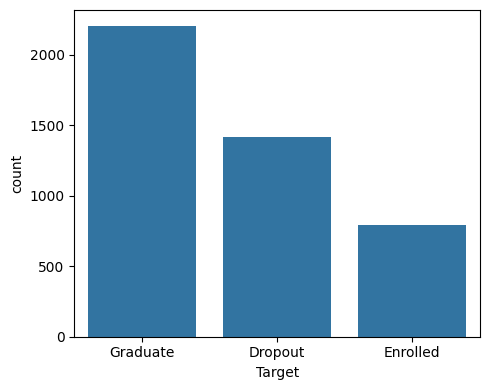

In [7]:
# Distribución de la variable objetivo
print(df["Target"].value_counts(normalize=True).round(3))
print("\ndropout binario:")
print(df["dropout"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Target", order=["Graduate", "Dropout", "Enrolled"], ax=ax)
plt.tight_layout()
plt.show()

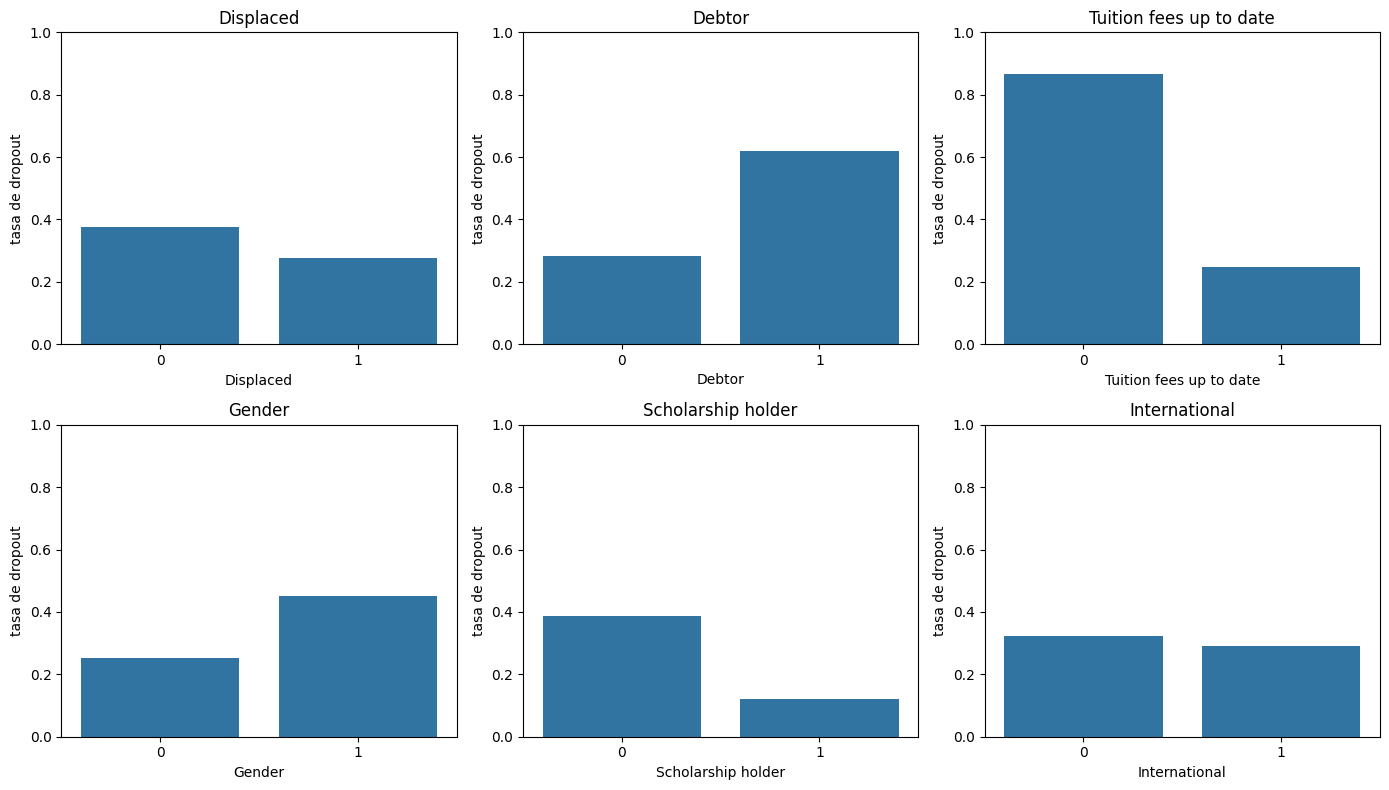

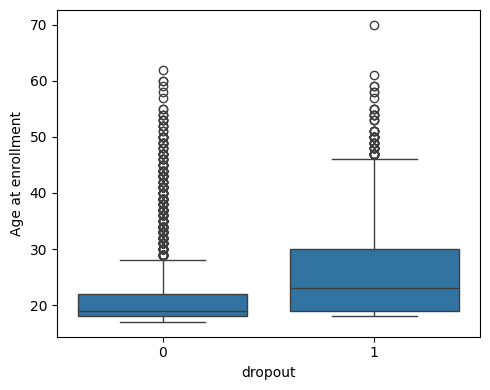

In [8]:
# Relaciones entre predictores personales y objetivo
binarias = ["Displaced", "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, binarias):
    tasa = df.groupby(col)["dropout"].mean()
    sns.barplot(x=tasa.index.astype(str), y=tasa.values, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("tasa de dropout")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Edad al matricularse, por dropout
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x="dropout", y="Age at enrollment", ax=ax)
plt.tight_layout()
plt.show()

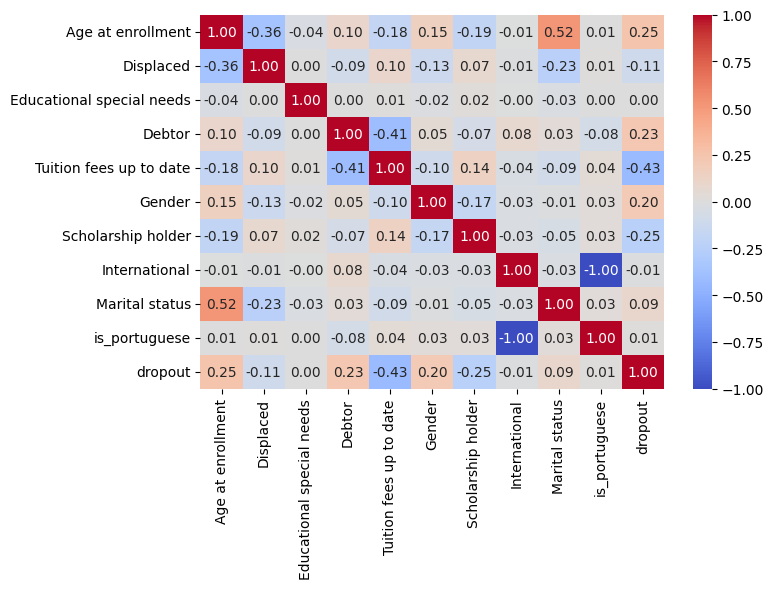

In [9]:
# Matriz de correlación (recordar: correlación no es causalidad)
df["is_portuguese"] = (df["Nacionality"] == 1).astype(int)

cols_corr = ["Age at enrollment", "Displaced", "Educational special needs", "Debtor",
             "Tuition fees up to date", "Gender", "Scholarship holder", "International",
             "Marital status", "is_portuguese", "dropout"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.show()

**Hallazgos del EDA (numerados, con la gráfica que los respalda):**

1. **Distribución del target (gráfica de barras del target):** 49.9% Graduate, 32.1% Dropout, 18.0% Enrolled. Es un desbalance moderado, no extremo (no es el caso 95/5 que exigiría cambiar de métrica): el baseline trivial de "siempre no-dropout" acierta 67.9% de las veces, así que cualquier modelo tiene que superar ese número, no un 50%.

2. **`Tuition fees up to date` (panel de barras):** es el predictor personal con más separación de todo el set. 86.6% de dropout entre quienes NO tienen las cuotas al día, contra 24.7% entre quienes sí (r = -0.43 con `dropout` en el mapa de calor) — la variable individual más fuerte de la sección.

3. **`Debtor` y `Scholarship holder` (panel de barras):** son dos caras de la misma situación económica. Ser deudor casi duplica la tasa de dropout (62.0% vs 28.3%, r = 0.23); tener beca la reduce a menos de un tercio (12.2% vs 38.7%, r = -0.25).

4. **`Gender` y `Age at enrollment` (panel de barras y boxplot):** los hombres abandonan más que las mujeres en este dataset (45.1% vs 25.1%, r = 0.20). Quienes abandonan se matriculan en promedio 4 años más tarde (26.1 vs 21.9 años; mediana 23 vs 19) y con más dispersión — la caja de `dropout=1` está claramente desplazada hacia arriba en el boxplot.

5. **Redundancia entre `International` y `is_portuguese` (mapa de calor):** ambas correlacionan perfectamente en sentido inverso (r = -1.00). No es casualidad: en este dataset los 110 estudiantes internacionales son exactamente los 110 no-portugueses, así que son la misma partición con otro nombre. Hay que usar solo una de las dos en la sección 6 para no duplicar la misma señal.

6. **Ninguna variable individual basta por sí sola (mapa de calor):** la correlación más fuerte con `dropout` es -0.43 (`Tuition fees up to date`); todas las demás están entre -0.25 y 0.25. El valor del modelo del baseline (sección 7) va a depender de combinar varias señales moderadas, no de una sola variable dominante.

## 6. Feature engineering

**Atención al leakage:** la partición train/test va antes de ajustar cualquier transformación que dependa de estadísticas del dataset (escalamiento, agrupar categorías raras). `is_portuguese` y `dropout` son excepciones seguras: son recodificaciones fijas de una sola fila (`Nacionality == 1`, `Target == "Dropout"`), no estadísticas agregadas, así que no importa si se calculan antes o después del split.

In [10]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "Age at enrollment", "Displaced", "Educational special needs", "Debtor",
    "Tuition fees up to date", "Gender", "Scholarship holder", "is_portuguese",
    "Marital status", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
]
# Nacionality queda fuera: ya está resumida en is_portuguese (sección 4).
# International queda fuera: es el complemento exacto de is_portuguese (sección 5, r=-1.00).

X = df[feature_cols]
y = df["dropout"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
# stratify=y porque el target está desbalanceado 68/32 (sección 5): sin esto,
# train y test podrían terminar con proporciones de dropout distintas por azar.

In [11]:
# Transformaciones dentro de un Pipeline: fit solo con train
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numericas = ["Age at enrollment", "Displaced", "Educational special needs", "Debtor",
             "Tuition fees up to date", "Gender", "Scholarship holder", "is_portuguese"]
categoricas = ["Marital status", "Mother's qualification", "Father's qualification",
               "Mother's occupation", "Father's occupation"]

preproceso = ColumnTransformer([
    ("num", StandardScaler(), numericas),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01), categoricas),
])

# Verificación rápida: el preproceso se ajusta solo con X_train
preproceso.fit(X_train)
preproceso.transform(X_train).shape

(3539, 53)

**Features y su justificación:**

| Feature | Cómo se construyó | Por qué debería ayudar |
|---|---|---|
| `is_portuguese` | `Nacionality == 1` | Colapsa ~20 categorías de nacionalidad (97.5% concentradas en una sola, sección 3) en una señal binaria estable, sin columnas casi vacías |
| Binarias personales (`Displaced`, `Educational special needs`, `Debtor`, `Tuition fees up to date`, `Gender`, `Scholarship holder`) | Tal cual, escaladas con `StandardScaler` | Ya vienen limpias (sección 4); `Tuition fees up to date`, `Debtor` y `Scholarship holder` mostraron la separación más fuerte con el target en la sección 5 |
| `Age at enrollment` | Tal cual, escalada con `StandardScaler` | Segunda correlación más fuerte con dropout (r = 0.25, sección 5) |
| `Marital status`, `Mother's/Father's qualification`, `Mother's/Father's occupation` | `OneHotEncoder(min_frequency=0.01)`: categorías con menos del 1% de las filas de entrenamiento se agrupan en un nivel "infrequent" | Son categóricas nominales de alta cardinalidad con muchos niveles raros (sección 3); agrupar automáticamente evita columnas casi vacías sin necesitar un diccionario semántico completo de los códigos de ocupación (no disponible) |
| Código "Unknown"/"(blank)" en datos de los padres | No se imputa: el `OneHotEncoder` lo trata como un nivel más | Su ausencia está asociada al abandono (73% vs. 32%, sección 4) — convertirlo en su propia categoría preserva esa señal en vez de borrarla |

**Features descartadas:**

| Variable | Por qué se descarta |
|---|---|
| `Nacionality` (cruda) | Reemplazada por `is_portuguese`; no aporta información adicional una vez colapsada |
| `International` | Es el complemento exacto de `is_portuguese` (r = -1.00, sección 5); incluir ambas duplicaría la misma señal |

## 7. Modelo baseline

In [12]:
# Baseline trivial: DummyClassifier
from sklearn.dummy import DummyClassifier

trivial = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
trivial.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='most_frequent')

In [13]:
# Modelo propuesto: k-NN, dentro del Pipeline (preproceso se ajusta solo con train)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Barrido ligero de k (no es tuning exhaustivo, solo para no elegir k al azar)
for k in [5, 11, 15, 21, 31, 51]:
    modelo_k = Pipeline([("preproceso", preproceso), ("knn", KNeighborsClassifier(n_neighbors=k))])
    modelo_k.fit(X_train, y_train)
    p_test = modelo_k.predict(X_test)
    print(f"k={k:3d}  test_acc={accuracy_score(y_test, p_test):.3f}  "
          f"test_f1={f1_score(y_test, p_test):.3f}")

# k=11 da el mejor balance precision/recall (F1) sin ser el que más sobreajusta
modelo = Pipeline([
    ("preproceso", preproceso),
    ("knn", KNeighborsClassifier(n_neighbors=11)),
])
modelo.fit(X_train, y_train)

k=  5  test_acc=0.754  test_f1=0.571
k= 11  test_acc=0.768  test_f1=0.565
k= 15  test_acc=0.764  test_f1=0.537
k= 21  test_acc=0.765  test_f1=0.523
k= 31  test_acc=0.763  test_f1=0.507
k= 51  test_acc=0.762  test_f1=0.496


Pipeline(steps=[('preproceso',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age at enrollment',
                                                   'Displaced',
                                                   'Educational special needs',
                                                   'Debtor',
                                                   'Tuition fees up to date',
                                                   'Gender',
                                                   'Scholarship holder',
                                                   'is_portuguese']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                min_frequency=0.01),
                                                  ['Marital status',
                                                   "Mother's qualification",
                                                   "Father's qualification",
                                                   "Mother's occupation",
                                                   "Father's occupation"])])),
                ('knn', KNeighborsClassifier(n_neighbors=11))])

In [14]:
# Evaluación en train y test. Target desbalanceado (68/32, sección 5): accuracy sola no
# alcanza, se reportan también precision/recall/F1 para la clase dropout (=1)
def reportar(nombre, modelo, X_, y_):
    p = modelo.predict(X_)
    print(f"{nombre:8s} acc={accuracy_score(y_, p):.3f}  "
          f"prec={precision_score(y_, p, zero_division=0):.3f}  "
          f"rec={recall_score(y_, p, zero_division=0):.3f}  "
          f"f1={f1_score(y_, p, zero_division=0):.3f}")

print("--- Trivial ---")
reportar("train", trivial, X_train, y_train)
reportar("test", trivial, X_test, y_test)

print("\n--- k-NN (k=11) ---")
reportar("train", modelo, X_train, y_train)
reportar("test", modelo, X_test, y_test)

--- Trivial ---
train    acc=0.679  prec=0.000  rec=0.000  f1=0.000
test     acc=0.679  prec=0.000  rec=0.000  f1=0.000

--- k-NN (k=11) ---
train    acc=0.786  prec=0.764  rec=0.482  f1=0.591
test     acc=0.768  prec=0.711  rec=0.468  f1=0.565


**Resultados:**

| Modelo | Accuracy (train) | Accuracy (test) | Precision (test) | Recall (test) | F1 (test) |
|---|---|---|---|---|---|
| Trivial (clase mayoritaria) | 0.679 | 0.679 | 0.000 | 0.000 | 0.000 |
| k-NN (k=11) | 0.786 | 0.768 | 0.711 | 0.468 | 0.565 |

El trivial nunca predice dropout (recall y precision en 0: solo repite "no abandona"), así que su 67.9% de accuracy es un piso, no un logro. El k-NN le gana en accuracy por 8.9 puntos (76.8% vs 67.9%) y, más importante, identifica correctamente el 46.8% de los estudiantes que sí abandonan (recall) con un 71.1% de precisión en esas predicciones — algo que el trivial no puede hacer en absoluto. La brecha train/test (78.6% vs 76.8%) es chica, así que no hay sobreajuste severo.

¿Vale la pena la complejidad extra? Sí, para el propósito del proyecto: una oficina de retención que solo usara el trivial no identificaría a ningún estudiante en riesgo. Pero el recall de 46.8% también dice que el modelo, usando solo información personal y socioeconómica, deja pasar a más de la mitad de quienes sí abandonan — consistente con el hallazgo de la sección 5 de que ninguna variable individual pasa de r=0.43 con el target.

## 8. Conclusiones y límites

**Respuesta a la pregunta:** usando solo información personal y socioeconómica, un k-NN baseline supera de forma clara al trivial (76.8% vs. 67.9% de accuracy en test) e identifica al 46.8% de los estudiantes que efectivamente abandonan, con 71.1% de precisión en esas predicciones — algo que predecir siempre "no abandona" no puede hacer. Es decir: la información personal **sí** explica una parte real del abandono, pero no la mayor parte. Un recall de 46.8% significa que más de la mitad de quienes abandonan no se distinguen del resto solo con este tipo de variables, consistente con que ninguna variable individual pasó de r = 0.43 con el target (sección 5). La señal más fuerte no fue demográfica en sentido estricto, sino financiero-administrativa: estar al día con la matrícula, no ser deudor y tener beca.

**Límites del análisis:**

- **Correlación no es causalidad.** Que `Tuition fees up to date` prediga bien el abandono no significa que atrasarse en el pago *cause* el abandono; ambos son plausiblemente efectos de una misma precariedad económica de fondo. No se puede afirmar causalidad con este diseño.
- **Muestra acotada.** Los datos vienen de una sola institución portuguesa, con cohortes de 2008/09 a 2018/19. No hay garantía de que estas relaciones se sostengan en otro país, otra institución o cohortes más recientes.
- **Alcance elegido, no falta de datos.** El dataset trae desempeño curricular y datos de admisión que deliberadamente dejamos fuera (sección 1) porque la pregunta era específicamente sobre información personal. Es muy probable que esas variables excluidas expliquen bastante más del abandono que las que usamos aquí — este proyecto responde una pregunta más angosta a propósito.
- **El propio patrón de faltantes es una señal que no explicamos.** El código "Unknown"/"(blank)" en los datos de los padres se asocia fuertemente con el abandono (73% vs. 32%, sección 4), pero no sabemos *por qué* falta ese dato — no se puede interpretar esa asociación como causal ni como una característica estable del estudiante.
- **Categorías raras y submuestreadas.** Nacionalidad, estado civil y varios códigos de ocupación tienen muy pocas observaciones (sección 3); el comportamiento del modelo en esos segmentos está poco probado.
- **Riesgo de uso indebido.** Usar género, estado civil o indicadores de dificultad económica para marcar "riesgo" tiene consecuencias reales si se aplica en la práctica (estigmatización, decisiones injustas); cualquier uso real necesitaría una revisión de equidad que este ejercicio de baseline no cubre.

**Qué haría falta para responderla mejor:**

- Comparar, con el mismo pipeline, el aporte marginal de "solo personal" vs. "personal + admisión" vs. "todo" para cuantificar cuánto se pierde al excluir variables académicas.
- Incorporar señales tempranas de desempeño (primera evaluación, asistencia) sin usar el semestre completo, para no adelantar información que no existiría al momento de intervenir.
- Probar el modelo en otra institución o cohorte para ver si las relaciones encontradas se sostienen fuera de esta muestra.
- Investigar la causa real detrás de los datos "Unknown" de los padres en vez de solo documentar la asociación con el abandono.

## 9. Bitácora de colaboración con AI

Usé Claude como asistente durante el proyecto.

**Qué le pedí:** Le pedí que me ayudará a refinar la redacción y hacerlo en markdown para pegar en las celdas del proyecto.

**En qué ayudó:**
- Me ayudó a escribir el código y con temas de las librerías como sklearn.
- Me ayudó a escribir comentarios dentro del código.
- Me ayudó en elegir tipos de gráficas para mostrar los distintos datos de forma atractiva.
- Verificó que cada bloque de código corriera como se tenía intencionado.

**Qué decidí yo:** Yo tomé decisiones de más alto nivel como el dataset para el proyecto, las variables a usar, la pregunta a atacar. Principalmente las partes encargadas del diseño del pryecto.

**Qué verifiqué yo:** ejecuté el notebook completo en mi máquina para verificar los resultados que Claude calculó por separado y los números coinciden. Antes de entregar, hice una lectura completa de la redacción y comentarios de Claude para confirmar que sean acorde a mi propio entendimiento.

## Anexo: peer critique (se llena en clase)

**Revisor:**

1. ¿Entendí la pregunta del proyecto sin preguntarle al autor?
* Sí
2. ¿Hay alguna gráfica o celda que yo borraría? ¿Cuál y por qué?
* La grafica Boxplot de DROPOUT con AGE AT ENROLLEMENT tiene una linea de datos indistingible en un bigote, recomendaria realizarla mas grande y mas definida tanto en ejes X y Y
3. ¿Veo algún punto donde se pudo haber colado información del test?
* La variable Scholarship holder considera que el estudiante tiene beca, pero no se describe la naturaleza de esta Beca: si posee oestudiantes con Beca completa y estudiantes con Beca parcial, estos datos generarian una corralacion con Tuition fees up to date, siendo esta dependiente de algunos datos de Scholarship holder.